# Filter basis functions

To parameterize spherical discrete-continuous (DISCO) convolutions, we need to pick suitable basis functions. Currently, torch-harmonics supports 3 different basis types:

* Picewise Linear basis functions (Similar to hat functions in finite element methods)
* Morlet-wavelet-like basis functions defined on the sphere
* Zernike polynomials

This notebook outlines depicts the different types of basis functions.

In [1]:
import math

import numpy as np
import torch

import matplotlib.pyplot as plt
cmap = plt.cm.RdBu

from torch_harmonics.filter_basis import get_filter_basis

## Piecewise linear basis on a disk

We start off with piecewise linear basis functions defined on a disk.

In [2]:
fb = get_filter_basis((5, 4), "piecewise linear")

/home/bbonev/.local/lib/python3.10/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


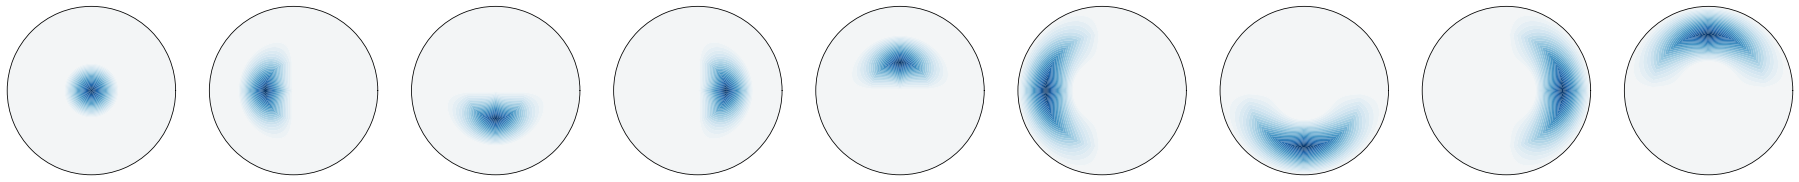

In [3]:
phi = torch.linspace(0, 2*np.pi, 100)
r = torch.linspace(0, 1.0, 40)
r, phi = torch.meshgrid(r, phi)

# Quadrature on the unit disk: area element r dr dφ. Trapezoidal in r, uniform in φ.
nr, nphi = r.shape[0], r.shape[1]
dr = 1.0 / (nr - 1) if nr > 1 else 1.0
dphi = 2 * math.pi / nphi
r_fac = torch.ones_like(r)
r_fac[0, :] = 0.5
r_fac[-1, :] = 0.5
quad_weights = r * dr * dphi * r_fac

ks = fb.kernel_size
idx, vals = fb.compute_support_vals(r, phi, r_cutoff=1)
idx = torch.stack([idx[:, 0], idx[:, 1], idx[:, 2]], dim=0)
psi = torch.sparse_coo_tensor(idx, vals, size=(ks, *r.shape)).to_dense()

fig, ax = plt.subplots(nrows=1, ncols=ks, subplot_kw={"projection": "polar"}, figsize=(32,4))
for k in range(0, ks):
    f = psi[k]
    pc = ax[k].contourf(phi, r, f, cmap=cmap, vmin=-f.abs().max(), vmax=f.abs().max(), levels=24, antialiased=True)
    ax[k].set_xticks([])
    ax[k].set_yticks([])

adding up all basis functions to obtain a filter

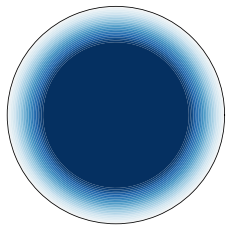

In [4]:
filter = (fb.get_init_factors().reshape(-1, 1, 1) * psi).sum(dim=0)

fig = plt.figure()
ax = fig.add_subplot(projection="polar")
ax.contourf(phi, r, filter, cmap=cmap, vmin=-filter.abs().max(), vmax=filter.abs().max(), levels=24, antialiased=True)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

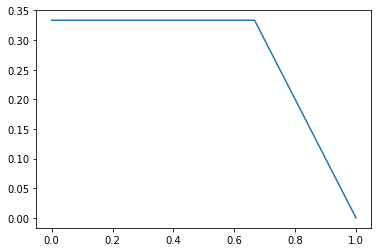

In [5]:
plt.plot(r[:, 0], filter[:, 0])

## Wavelet style basis

This basis uses a Hann windowing function and a Fourier basis.

In [6]:
nmax = mmax = 3
fb = get_filter_basis((nmax, mmax), "harmonic")

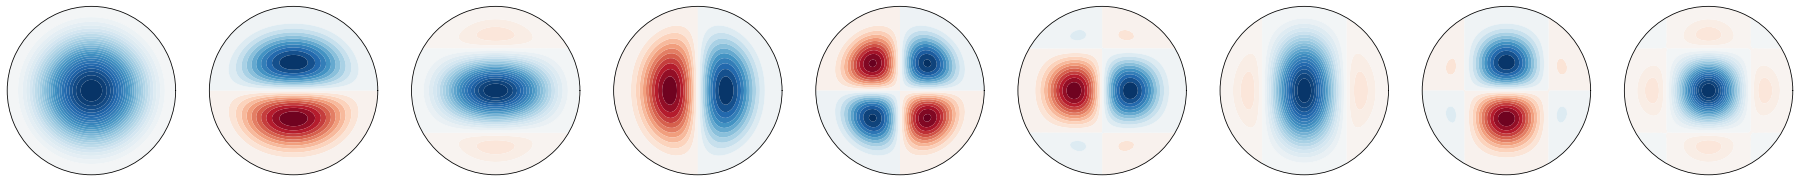

In [7]:
phi = torch.linspace(0, 2*np.pi, 100)
r = torch.linspace(0, 1.0, 40)
r, phi = torch.meshgrid(r, phi)

ks = fb.kernel_size
idx, vals = fb.compute_support_vals(r, phi, r_cutoff=1)
idx = torch.stack([idx[:, 0], idx[:, 1], idx[:, 2]], dim=0)
psi = torch.sparse_coo_tensor(idx, vals, size=(ks, *r.shape)).to_dense()

fig, ax = plt.subplots(nrows=1, ncols=ks, subplot_kw={"projection": "polar"}, figsize=(32,4))
for k in range(0, ks):
    f = psi[k]
    pc = ax[k].contourf(phi, r, f, cmap=cmap, vmin=-f.abs().max(), vmax=f.abs().max(), levels=24, antialiased=True)
    ax[k].set_xticks([])
    ax[k].set_yticks([])

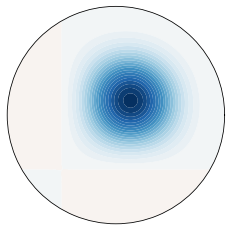

In [8]:
filter = (fb.get_init_factors().reshape(-1, 1, 1) * psi).sum(dim=0)

fig = plt.figure()
ax = fig.add_subplot(projection="polar")
ax.contourf(phi, r, filter, cmap=cmap, vmin=-filter.abs().max(), vmax=filter.abs().max(), levels=24, antialiased=True)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [9]:
dr = r[1, 0] - r[0, 0]
dphi = phi[0, 1] - phi[0, 0]
norms_sq = (psi**2 * r.unsqueeze(0) * dr * dphi).sum(dim=(-2, -1))
print("L2 norms (should be ~1):", norms_sq.sqrt())

L2 norms (should be ~1): tensor([0.7393, 0.4672, 0.5730, 0.4710, 0.2922, 0.3694, 0.5699, 0.3646, 0.4380])


## Zernike polynomials

for more info read [https://en.wikipedia.org/wiki/Zernike_polynomials](https://en.wikipedia.org/wiki/Zernike_polynomials)

In [10]:
nmax = 4
fb = get_filter_basis(nmax, "zernike")

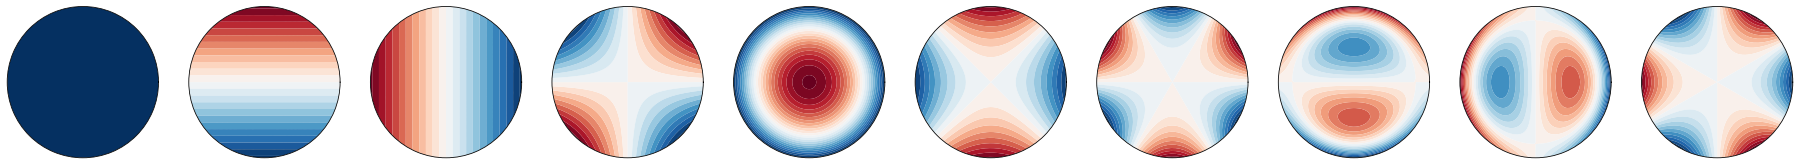

In [11]:
phi = torch.linspace(0, 2*np.pi, 100)
r = torch.linspace(0, 1.0, 40)
r, phi = torch.meshgrid(r, phi)

ks = fb.kernel_size
idx, vals = fb.compute_support_vals(r, phi, r_cutoff=1)
idx = torch.stack([idx[:, 0], idx[:, 1], idx[:, 2]], dim=0)
psi = torch.sparse_coo_tensor(idx, vals, size=(ks, *r.shape)).to_dense()

fig, ax = plt.subplots(nrows=1, ncols=ks, subplot_kw={"projection": "polar"}, figsize=(32,4))
for k in range(0, ks):
    f = psi[k]
    pc = ax[k].contourf(phi, r, f, cmap=cmap, vmin=-f.abs().max(), vmax=f.abs().max(), levels=24, antialiased=True)
    ax[k].set_xticks([])
    ax[k].set_yticks([])

add abasis function to obtain a filter

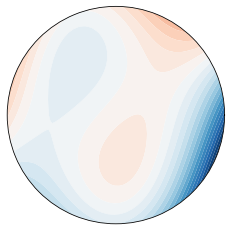

In [12]:
filter = (fb.get_init_factors().reshape(-1, 1, 1) * psi).sum(dim=0)

fig = plt.figure()
ax = fig.add_subplot(projection="polar")
ax.contourf(phi, r, filter, cmap=cmap, vmin=-filter.abs().max(), vmax=filter.abs().max(), levels=24, antialiased=True)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

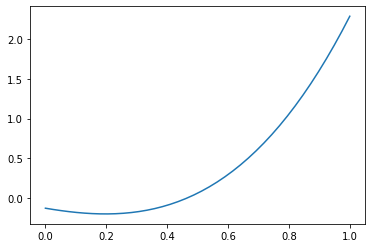

In [13]:
plt.plot(r[:, 0], filter[:, 0])

In [14]:
dr = r[1, 0] - r[0, 0]
dphi = phi[0, 1] - phi[0, 0]
norms_sq = (psi**2 * r.unsqueeze(0) * dr * dphi).sum(dim=(-2, -1))
print("L2 norms (should be ~1):", norms_sq.sqrt())

L2 norms (should be ~1): tensor([1.0178, 1.0256, 1.0359, 1.0385, 1.0442, 1.0490, 1.0515, 1.0532, 1.0637,
        1.0621])


## Fourier-Bessel Basis

The Fourier-Bessel Basis functions on a disk are defined as

$$
\Psi_{m, n} (r, \theta) = J_m(\alpha_{m, n} r) \cos(m \theta)
$$

Unlike, the Zernike polynomials, the Fourier-Bessel basis functiosn vanish smoothly to $0$ at the boundary, which is advantageous for filtering and leakage purposes.

In [15]:
kernel_shape = (3,3)
fb = get_filter_basis(kernel_shape=kernel_shape, basis_type="fourier-bessel")
print(fb.kernel_size)

13


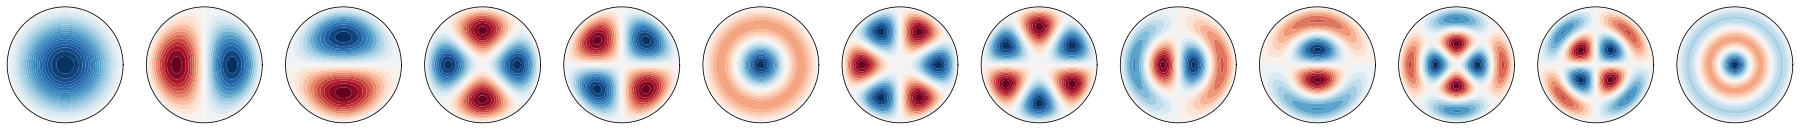

In [16]:
phi = torch.linspace(0, 2*np.pi, 100)
r = torch.linspace(0, 1.0, 40)
r, phi = torch.meshgrid(r, phi)

ks = fb.kernel_size
idx, vals = fb.compute_support_vals(r, phi, r_cutoff=1)
idx = torch.stack([idx[:, 0], idx[:, 1], idx[:, 2]], dim=0)
psi = torch.sparse_coo_tensor(idx, vals, size=(ks, *r.shape)).to_dense()

fig, ax = plt.subplots(nrows=1, ncols=ks, subplot_kw={"projection": "polar"}, figsize=(32,4))
for k in range(0, ks):
    f = psi[k]
    pc = ax[k].contourf(phi, r, f, cmap=cmap, vmin=-f.abs().max(), vmax=f.abs().max(), levels=24, antialiased=True)
    ax[k].set_xticks([])
    ax[k].set_yticks([])

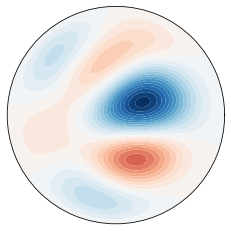

In [17]:
filter = (fb.get_init_factors().reshape(-1, 1, 1) * psi).sum(dim=0)

fig = plt.figure()
ax = fig.add_subplot(projection="polar")
ax.contourf(phi, r, filter, cmap=cmap, vmin=-filter.abs().max(), vmax=filter.abs().max(), levels=24, antialiased=True)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

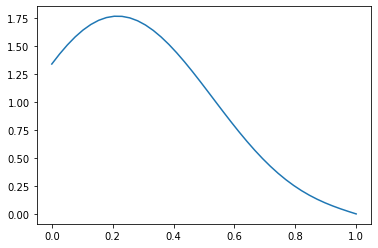

In [18]:
plt.plot(r[:, 0], filter[:, 0])

In [19]:
# R = 1.0
# phi = torch.linspace(0, 2*np.pi, 100)
# r = torch.linspace(0, R, 40)
# r, phi = torch.meshgrid(r, phi)

# # Quadrature on the unit disk: area element r dr dφ. Trapezoidal in r, uniform in φ.
# nr, nphi = r.shape[0], r.shape[1]
# dr = R / (nr - 1) if nr > 1 else 1.0
# dphi = 2 * math.pi / nphi
# r_fac = torch.ones_like(r)
# r_fac[0, :] = 0.5
# r_fac[-1, :] = 0.5
# quad_weights = r * dr * dphi * r_fac

In [20]:
# (quad_weights * psi[3].abs().pow(2)).sum().sqrt()

In [21]:
dr = r[1, 0] - r[0, 0]
dphi = phi[0, 1] - phi[0, 0]
norms_sq = (psi**2 * r.unsqueeze(0) * dr * dphi).sum(dim=(-2, -1))
print("L2 norms (should be ~1):", norms_sq.sqrt())

L2 norms (should be ~1): tensor([1.0048, 1.0101, 1.0000, 1.0101, 1.0000, 1.0046, 1.0101, 1.0000, 1.0101,
        1.0000, 1.0101, 1.0000, 1.0043])
